In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the sales dataset

file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Inspect the dataset

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Data cleaning

# Make a copy so the original dataset remains unchanged
sales = df.copy()

# Remove rows with missing product descriptions
sales = sales.dropna(subset=["Description"])

# Convert InvoiceDate to datetime
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])

# Remove cancelled invoices
# Cancelled invoices in this dataset have InvoiceNo beginning with "C"
sales = sales[~sales["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
sales = sales[sales["Quantity"] > 0]
sales = sales[sales["UnitPrice"] > 0]

# Calculate revenue for each transaction
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

print("Original rows:", len(df))
print("Rows after cleaning:", len(sales))
print("Rows removed:", len(df) - len(sales))

print("\nCleaned dataset:")
sales.head()

Original rows: 541909
Rows after cleaning: 530104
Rows removed: 11805

Cleaned dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
# Verify the cleaned dataset

print("Missing values after cleaning:")
print(sales.isnull().sum())

print("\nCleaned dataset shape:")
print(sales.shape)

print("\nRevenue summary:")
print(sales["Revenue"].describe())

Missing values after cleaning:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
Revenue             0
dtype: int64

Cleaned dataset shape:
(530104, 9)

Revenue summary:
count    530104.000000
mean         20.121871
std         270.356743
min           0.001000
25%           3.750000
50%           9.900000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64


In [6]:
# Create daily sales data

sales["Date"] = sales["InvoiceDate"].dt.date

daily_sales = (
    sales.groupby("Date")["Revenue"]
    .sum()
    .reset_index()
)

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

# Sort chronologically
daily_sales = daily_sales.sort_values("Date").reset_index(drop=True)

print("Daily sales dataset created!")
print("Number of days:", len(daily_sales))

daily_sales.head(10)

Daily sales dataset created!
Number of days: 305


,Date,Revenue
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46
5,2010-12-07,99618.20
6,2010-12-08,45389.98
7,2010-12-09,53586.18
8,2010-12-10,59182.92
9,2010-12-12,17329.07


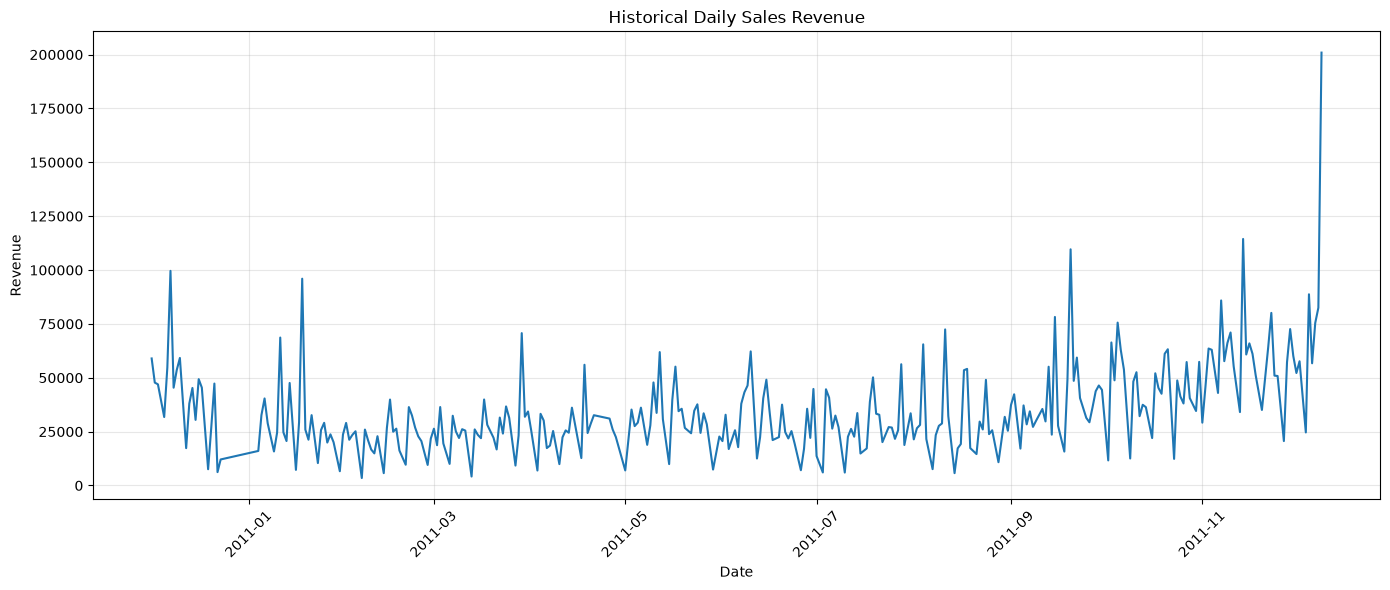

In [7]:
# Visualize historical daily sales

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"]
)

plt.title("Historical Daily Sales Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
# Time-based feature engineering

daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek
daily_sales["WeekOfYear"] = daily_sales["Date"].dt.isocalendar().week.astype(int)

# Lag features - previous sales information
daily_sales["Lag_1"] = daily_sales["Revenue"].shift(1)
daily_sales["Lag_7"] = daily_sales["Revenue"].shift(7)

# Rolling average based only on prior observations
daily_sales["Rolling_7"] = (
    daily_sales["Revenue"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

# Remove rows where lag features are unavailable
daily_sales = daily_sales.dropna().reset_index(drop=True)

print("Time-based features created successfully!")

daily_sales.head()

Time-based features created successfully!


,Date,Revenue,Year,Month,Day,DayOfWeek,WeekOfYear,Lag_1,Lag_7,Rolling_7
0,2010-12-09,53586.18,2010,12,9,3,49,45389.98,58960.79,55038.067143
1,2010-12-10,59182.92,2010,12,10,4,49,53586.18,47748.38,54270.265714
2,2010-12-12,17329.07,2010,12,12,6,49,59182.92,46943.71,55903.771429
3,2010-12-13,38006.71,2010,12,13,0,50,17329.07,31774.95,51673.108571
4,2010-12-14,45254.73,2010,12,14,1,50,38006.71,54830.46,52563.360000


In [9]:
# Prepare features for forecasting

features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Lag_1",
    "Lag_7",
    "Rolling_7"
]

X = daily_sales[features]
y = daily_sales["Revenue"]

# Chronological 80/20 split
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(daily_sales["Date"].iloc[0], "to", daily_sales["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(daily_sales["Date"].iloc[split_index], "to", daily_sales["Date"].iloc[-1])

Training samples: 238
Testing samples: 60

Training period:
2010-12-09 00:00:00 to 2011-09-30 00:00:00

Testing period:
2011-10-02 00:00:00 to 2011-12-09 00:00:00


In [10]:
# Train the Random Forest forecasting model

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [11]:
# Generate predictions

y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
-----------------
MAE  : 16980.11
RMSE : 27332.03
R²   : -0.0239


In [12]:
# Create a results DataFrame

results = pd.DataFrame({
    "Date": daily_sales["Date"].iloc[split_index:].values,
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred
})

results.head(10)

,Date,Actual_Revenue,Predicted_Revenue
0,2011-10-02,11634.53,23562.929355
1,2011-10-03,66376.82,43046.935715
2,2011-10-04,48810.65,59049.803145
3,2011-10-05,75593.63,47106.173495
4,2011-10-06,62891.19,49066.268655
5,2011-10-07,53790.70,49675.232055
6,2011-10-09,12524.40,24943.674730
7,2011-10-10,48239.18,42101.482910
8,2011-10-11,52572.94,46810.044625
9,2011-10-12,32159.28,46292.088000


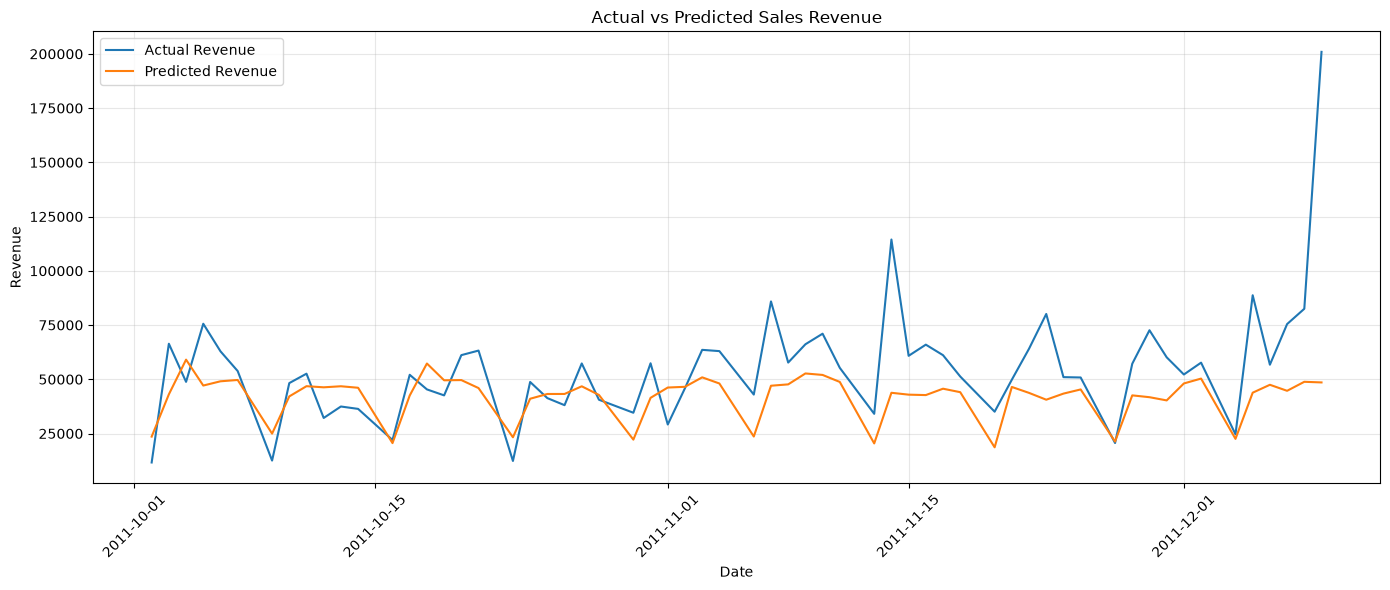

In [13]:
# Actual vs Predicted Revenue

plt.figure(figsize=(14, 6))

plt.plot(
    results["Date"],
    results["Actual_Revenue"],
    label="Actual Revenue"
)

plt.plot(
    results["Date"],
    results["Predicted_Revenue"],
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Sales Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [14]:
# Feature importance analysis

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

      Feature  Importance
3   DayOfWeek    0.275120
7   Rolling_7    0.196231
4  WeekOfYear    0.155843
6       Lag_7    0.138494
5       Lag_1    0.108250
2         Day    0.093950
1       Month    0.028203
0        Year    0.003908


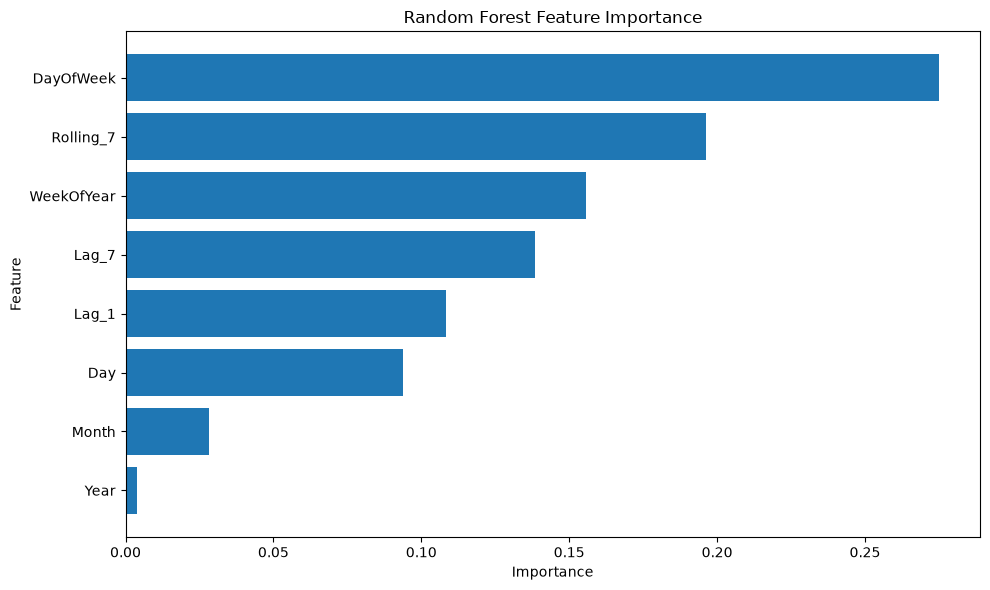

In [15]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
# Baseline forecast using the previous 7-day lag

baseline_pred = X_test["Lag_7"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Performance")
print("--------------------")
print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Performance
--------------------
MAE  : 24690.63
RMSE : 33167.26
R²   : -0.5077


In [17]:
# Compare model and baseline

comparison = pd.DataFrame({
    "Model": ["Random Forest", "7-Day Lag Baseline"],
    "MAE": [mae, baseline_mae],
    "RMSE": [rmse, baseline_rmse],
    "R2": [r2, baseline_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,16980.106286,27332.034730,-0.023871
1,7-Day Lag Baseline,24690.628467,33167.258671,-0.507719


In [18]:
# Improved time-series features

improved_sales = daily_sales.copy()

# Additional lag features
improved_sales["Lag_2"] = improved_sales["Revenue"].shift(2)
improved_sales["Lag_3"] = improved_sales["Revenue"].shift(3)
improved_sales["Lag_7"] = improved_sales["Revenue"].shift(7)
improved_sales["Lag_14"] = improved_sales["Revenue"].shift(14)

# Rolling statistics based only on previous observations
improved_sales["Rolling_3"] = (
    improved_sales["Revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)

improved_sales["Rolling_7"] = (
    improved_sales["Revenue"]
    .shift(1)
    .rolling(7)
    .mean()
)

improved_sales["Rolling_14"] = (
    improved_sales["Revenue"]
    .shift(1)
    .rolling(14)
    .mean()
)

# Remove rows created with missing lag values
improved_sales = improved_sales.dropna().reset_index(drop=True)

print("Improved features created!")
print("Rows available:", len(improved_sales))

Improved features created!
Rows available: 284


In [19]:
# Prepare improved features

improved_features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Rolling_3",
    "Rolling_7",
    "Rolling_14"
]

X_improved = improved_sales[improved_features]
y_improved = improved_sales["Revenue"]

# Chronological 80/20 split
split_index_improved = int(len(improved_sales) * 0.8)

X_train_improved = X_improved.iloc[:split_index_improved]
X_test_improved = X_improved.iloc[split_index_improved:]

y_train_improved = y_improved.iloc[:split_index_improved]
y_test_improved = y_improved.iloc[split_index_improved:]

print("Training samples:", len(X_train_improved))
print("Testing samples:", len(X_test_improved))


Training samples: 227
Testing samples: 57


In [20]:
# Train improved Random Forest model

improved_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

improved_model.fit(X_train_improved, y_train_improved)

print("Improved Random Forest trained successfully!")

Improved Random Forest trained successfully!


In [21]:
# Evaluate improved model

improved_pred = improved_model.predict(X_test_improved)

improved_mae = mean_absolute_error(
    y_test_improved,
    improved_pred
)

improved_rmse = np.sqrt(
    mean_squared_error(
        y_test_improved,
        improved_pred
    )
)

improved_r2 = r2_score(
    y_test_improved,
    improved_pred
)

print("Improved Model Performance")
print("--------------------------")
print(f"MAE  : {improved_mae:.2f}")
print(f"RMSE : {improved_rmse:.2f}")
print(f"R²   : {improved_r2:.4f}")

Improved Model Performance
--------------------------
MAE  : 16170.46
RMSE : 26871.50
R²   : 0.0130


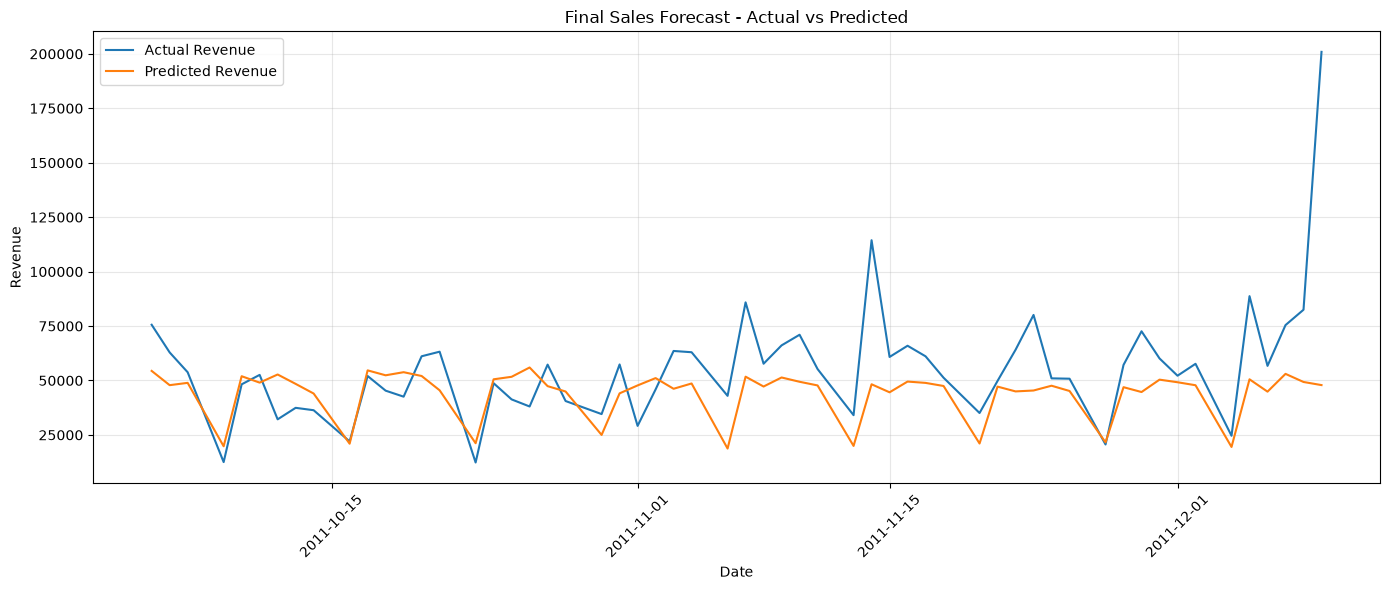

In [22]:
# Final actual vs predicted revenue

improved_results = pd.DataFrame({
    "Date": improved_sales["Date"].iloc[split_index_improved:].values,
    "Actual_Revenue": y_test_improved.values,
    "Predicted_Revenue": improved_pred
})

plt.figure(figsize=(14, 6))

plt.plot(
    improved_results["Date"],
    improved_results["Actual_Revenue"],
    label="Actual Revenue"
)

plt.plot(
    improved_results["Date"],
    improved_results["Predicted_Revenue"],
    label="Predicted Revenue"
)

plt.title("Final Sales Forecast - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [23]:
# Feature importance of the improved model

feature_importance = pd.DataFrame({
    "Feature": improved_features,
    "Importance": improved_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
3    DayOfWeek    0.258283
4   WeekOfYear    0.181705
9       Lag_14    0.088099
8        Lag_7    0.077903
7        Lag_3    0.073780
6        Lag_2    0.073706
10   Rolling_3    0.052619
12  Rolling_14    0.051250
11   Rolling_7    0.051231
5        Lag_1    0.039124
2          Day    0.036306
1        Month    0.015995
0         Year    0.000000


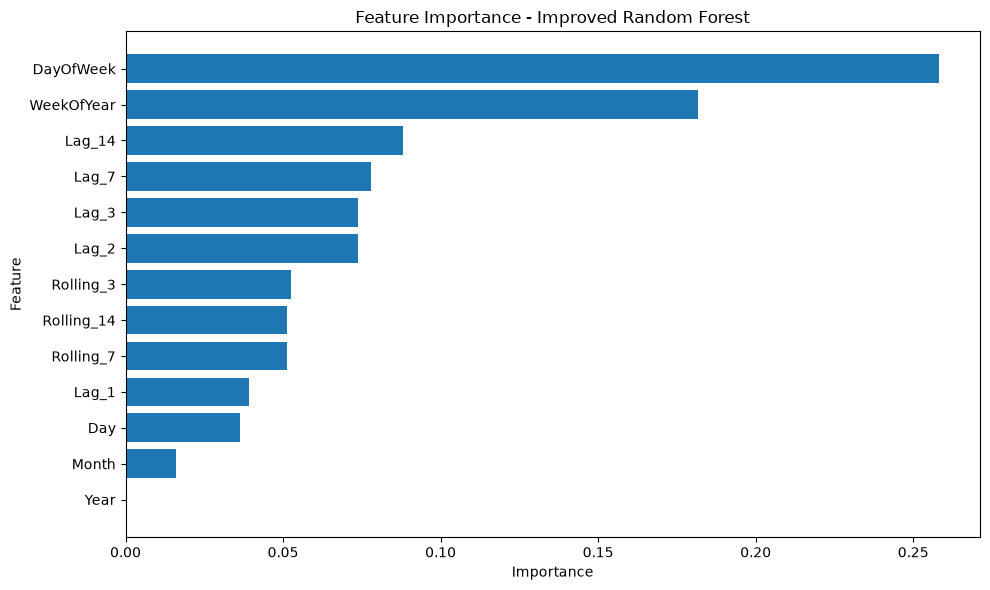

In [24]:
# Visualize and save feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Improved Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../visualizations/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Forecast error analysis

improved_results["Error"] = (
    improved_results["Actual_Revenue"]
    - improved_results["Predicted_Revenue"]
)

improved_results["Absolute_Error"] = (
    improved_results["Error"].abs()
)

print("Error Analysis")
print("--------------")
print(f"Mean Absolute Error: {improved_results['Absolute_Error'].mean():.2f}")
print(f"Maximum Absolute Error: {improved_results['Absolute_Error'].max():.2f}")

print("\nLargest forecast errors:")
print(
    improved_results
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

Error Analysis
--------------
Mean Absolute Error: 16170.46
Maximum Absolute Error: 153032.09

Largest forecast errors:
         Date  Actual_Revenue  Predicted_Revenue          Error  \
56 2011-12-09       200920.60       47888.511973  153032.088027   
34 2011-11-14       114419.89       48263.338045   66156.551955   
52 2011-12-05        88741.96       50540.321013   38201.638987   
42 2011-11-23        80104.18       45400.387689   34703.792311   
28 2011-11-07        85881.81       51753.780981   34128.029019   
55 2011-12-08        82495.00       49317.667815   33177.332185   
47 2011-11-29        72595.93       44700.492689   27895.437311   
27 2011-11-06        42946.34       18740.610500   24205.729500   
54 2011-12-07        75439.16       53044.119060   22395.040940   
31 2011-11-10        71008.26       49411.132498   21597.127502   

    Absolute_Error  
56   153032.088027  
34    66156.551955  
52    38201.638987  
42    34703.792311  
28    34128.029019  
55    33177.3321

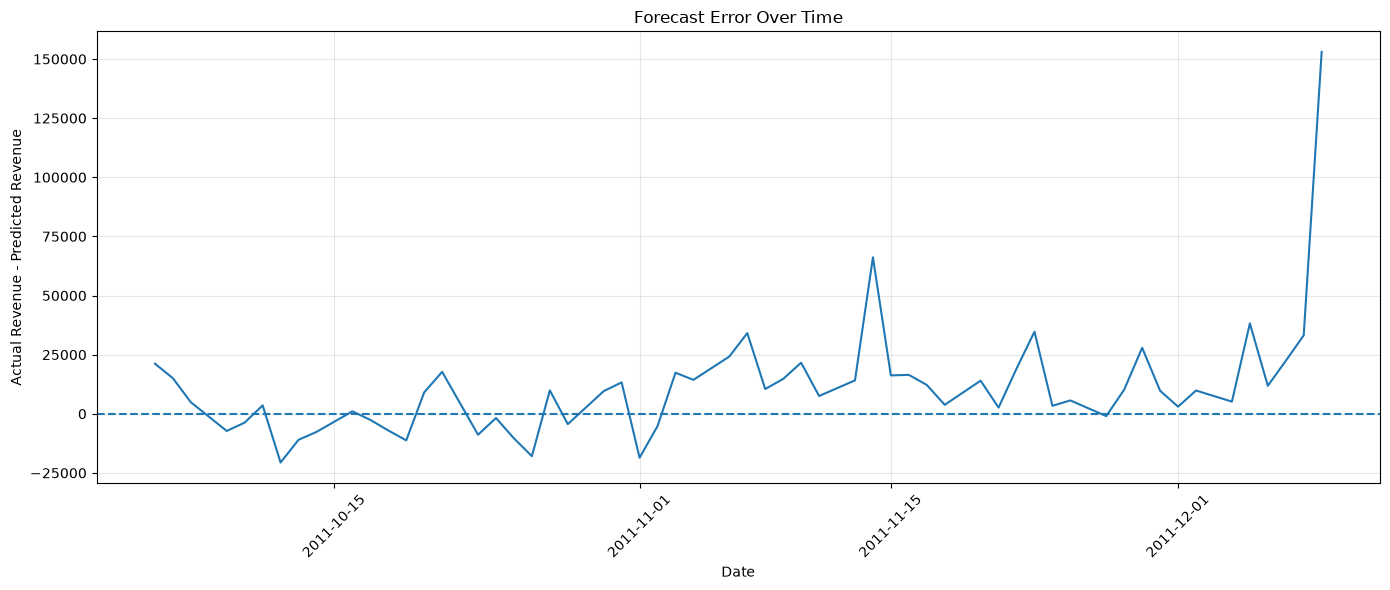

In [26]:
# Forecast error over time

plt.figure(figsize=(14, 6))

plt.plot(
    improved_results["Date"],
    improved_results["Error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Forecast Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual Revenue - Predicted Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../visualizations/forecast_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Business-level sales insights

total_revenue = sales["Revenue"].sum()
average_daily_revenue = daily_sales["Revenue"].mean()
maximum_daily_revenue = daily_sales["Revenue"].max()
minimum_daily_revenue = daily_sales["Revenue"].min()

best_day = daily_sales.loc[daily_sales["Revenue"].idxmax()]
worst_day = daily_sales.loc[daily_sales["Revenue"].idxmin()]

print("BUSINESS SALES INSIGHTS")
print("=======================")

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Daily Revenue: {average_daily_revenue:,.2f}")
print(f"Maximum Daily Revenue: {maximum_daily_revenue:,.2f}")
print(f"Minimum Daily Revenue: {minimum_daily_revenue:,.2f}")

print("\nHighest Revenue Day:")
print(best_day[["Date", "Revenue"]])

print("\nLowest Revenue Day:")
print(worst_day[["Date", "Revenue"]])

BUSINESS SALES INSIGHTS
Total Revenue: 10,666,684.54
Average Daily Revenue: 34,501.40
Maximum Daily Revenue: 200,920.60
Minimum Daily Revenue: 3,457.11

Highest Revenue Day:
Date       2011-12-09 00:00:00
Revenue               200920.6
Name: 297, dtype: object

Lowest Revenue Day:
Date       2011-02-06 00:00:00
Revenue                3457.11
Name: 41, dtype: object


In [28]:
# Monthly revenue analysis

monthly_sales = (
    sales.assign(
        YearMonth=sales["InvoiceDate"].dt.to_period("M")
    )
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

print("Monthly Revenue:")
print(monthly_sales)

Monthly Revenue:
   YearMonth      Revenue
0    2010-12   823746.140
1    2011-01   691364.560
2    2011-02   523631.890
3    2011-03   717639.360
4    2011-04   537808.621
5    2011-05   770536.020
6    2011-06   761739.900
7    2011-07   719221.191
8    2011-08   759138.380
9    2011-09  1058590.172
10   2011-10  1154979.300
11   2011-11  1509496.330
12   2011-12   638792.680


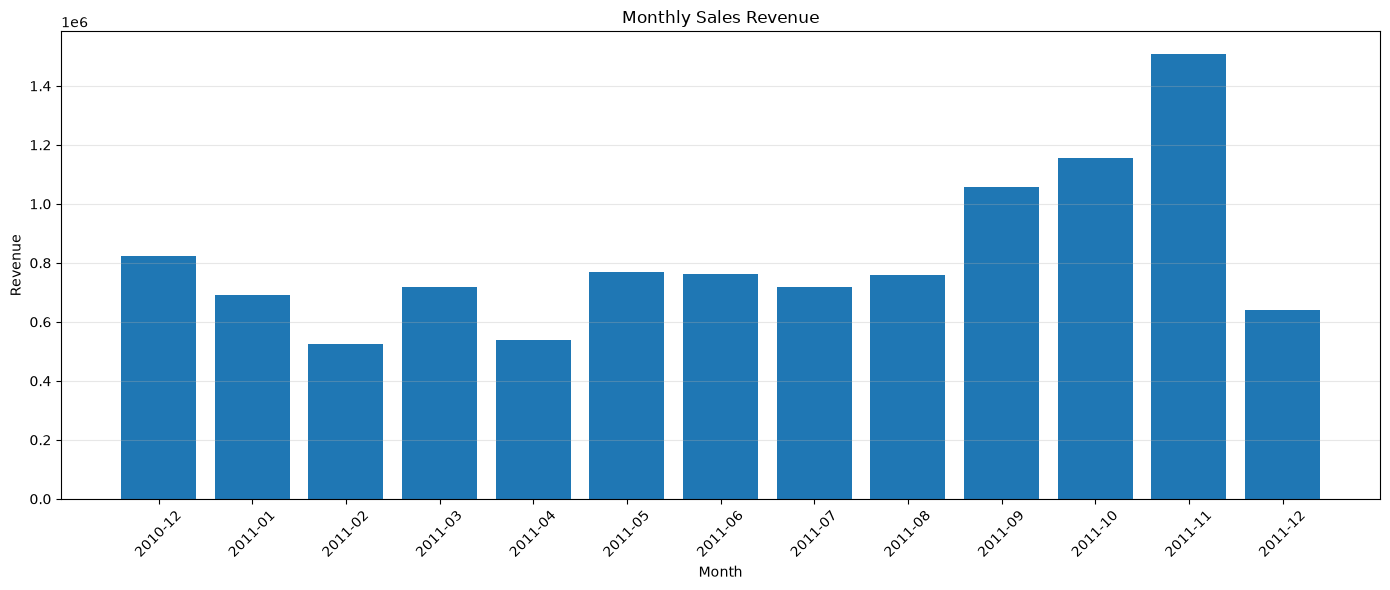

In [29]:
# Monthly revenue visualization

plt.figure(figsize=(14, 6))

plt.bar(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"]
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "7-Day Lag Baseline",
        "Improved Random Forest"
    ],
    "MAE": [
        mae,
        baseline_mae,
        improved_mae
    ],
    "RMSE": [
        rmse,
        baseline_rmse,
        improved_rmse
    ],
    "R2": [
        r2,
        baseline_r2,
        improved_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R2
0,Original Random Forest,16980.106286,27332.034730,-0.023871
1,7-Day Lag Baseline,24690.628467,33167.258671,-0.507719
2,Improved Random Forest,16170.463584,26871.497475,0.012968


In [31]:
# Final Business Insights

total_revenue = sales["Revenue"].sum()
average_daily_revenue = daily_sales["Revenue"].mean()
maximum_daily_revenue = daily_sales["Revenue"].max()
minimum_daily_revenue = daily_sales["Revenue"].min()

best_day = daily_sales.loc[daily_sales["Revenue"].idxmax()]
worst_day = daily_sales.loc[daily_sales["Revenue"].idxmin()]

print("FINAL BUSINESS INSIGHTS")
print("=======================")

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Daily Revenue: {average_daily_revenue:,.2f}")
print(f"Maximum Daily Revenue: {maximum_daily_revenue:,.2f}")
print(f"Minimum Daily Revenue: {minimum_daily_revenue:,.2f}")

print("\nHighest Revenue Day:")
print(best_day[["Date", "Revenue"]])

print("\nLowest Revenue Day:")
print(worst_day[["Date", "Revenue"]])

FINAL BUSINESS INSIGHTS
Total Revenue: 10,666,684.54
Average Daily Revenue: 34,501.40
Maximum Daily Revenue: 200,920.60
Minimum Daily Revenue: 3,457.11

Highest Revenue Day:
Date       2011-12-09 00:00:00
Revenue               200920.6
Name: 297, dtype: object

Lowest Revenue Day:
Date       2011-02-06 00:00:00
Revenue                3457.11
Name: 41, dtype: object


In [32]:
# Monthly revenue analysis

monthly_sales = (
    sales.assign(
        YearMonth=sales["InvoiceDate"].dt.to_period("M")
    )
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

print("Monthly Revenue:")
print(monthly_sales)

Monthly Revenue:
   YearMonth      Revenue
0    2010-12   823746.140
1    2011-01   691364.560
2    2011-02   523631.890
3    2011-03   717639.360
4    2011-04   537808.621
5    2011-05   770536.020
6    2011-06   761739.900
7    2011-07   719221.191
8    2011-08   759138.380
9    2011-09  1058590.172
10   2011-10  1154979.300
11   2011-11  1509496.330
12   2011-12   638792.680


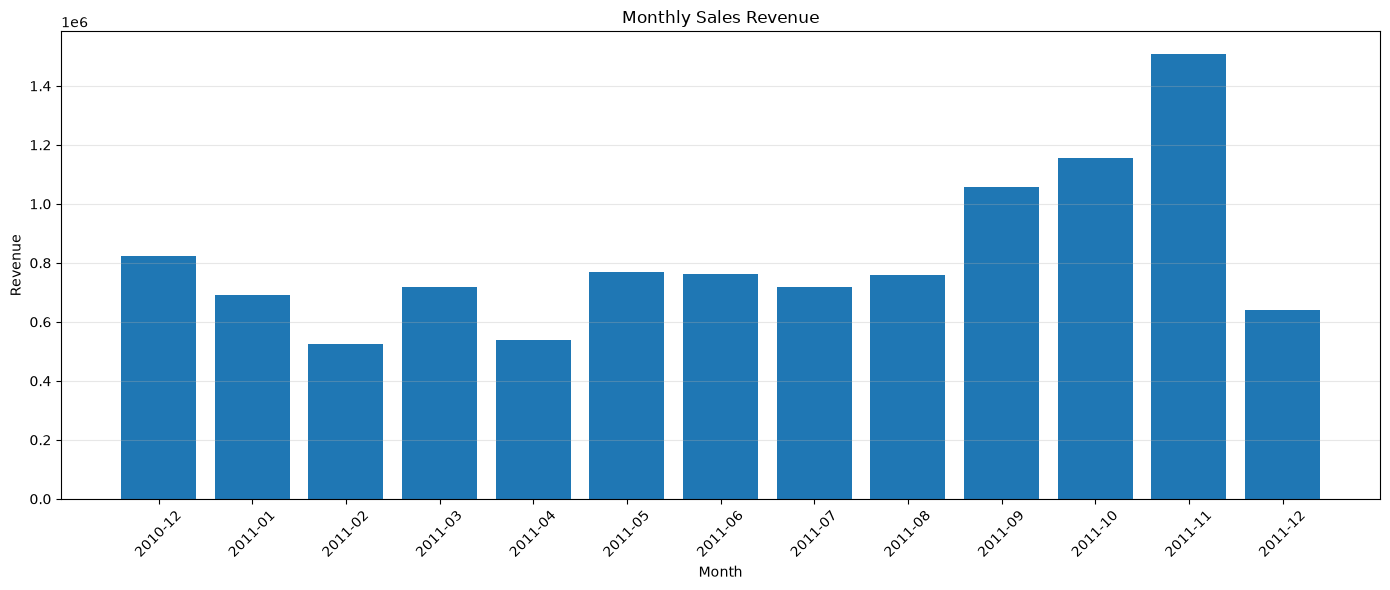

In [33]:
# Monthly Revenue Visualization

plt.figure(figsize=(14, 6))

plt.bar(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"]
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# Final Business Insights

total_revenue = sales["Revenue"].sum()
average_daily_revenue = daily_sales["Revenue"].mean()
maximum_daily_revenue = daily_sales["Revenue"].max()
minimum_daily_revenue = daily_sales["Revenue"].min()

best_day = daily_sales.loc[daily_sales["Revenue"].idxmax()]
worst_day = daily_sales.loc[daily_sales["Revenue"].idxmin()]

print("FINAL BUSINESS INSIGHTS")
print("=======================")

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Daily Revenue: {average_daily_revenue:,.2f}")
print(f"Maximum Daily Revenue: {maximum_daily_revenue:,.2f}")
print(f"Minimum Daily Revenue: {minimum_daily_revenue:,.2f}")

print("\nHighest Revenue Day:")
print(best_day[["Date", "Revenue"]])

print("\nLowest Revenue Day:")
print(worst_day[["Date", "Revenue"]])

FINAL BUSINESS INSIGHTS
Total Revenue: 10,666,684.54
Average Daily Revenue: 34,501.40
Maximum Daily Revenue: 200,920.60
Minimum Daily Revenue: 3,457.11

Highest Revenue Day:
Date       2011-12-09 00:00:00
Revenue               200920.6
Name: 297, dtype: object

Lowest Revenue Day:
Date       2011-02-06 00:00:00
Revenue                3457.11
Name: 41, dtype: object


In [35]:
# Final model performance summary

print("FINAL MODEL PERFORMANCE")
print("=======================")
print(f"MAE  : {improved_mae:,.2f}")
print(f"RMSE : {improved_rmse:,.2f}")
print(f"R²   : {improved_r2:.4f}")

print("\nModel: Improved Random Forest")
print("Evaluation: Chronological 80/20 train-test split")

FINAL MODEL PERFORMANCE
MAE  : 16,170.46
RMSE : 26,871.50
R²   : 0.0130

Model: Improved Random Forest
Evaluation: Chronological 80/20 train-test split


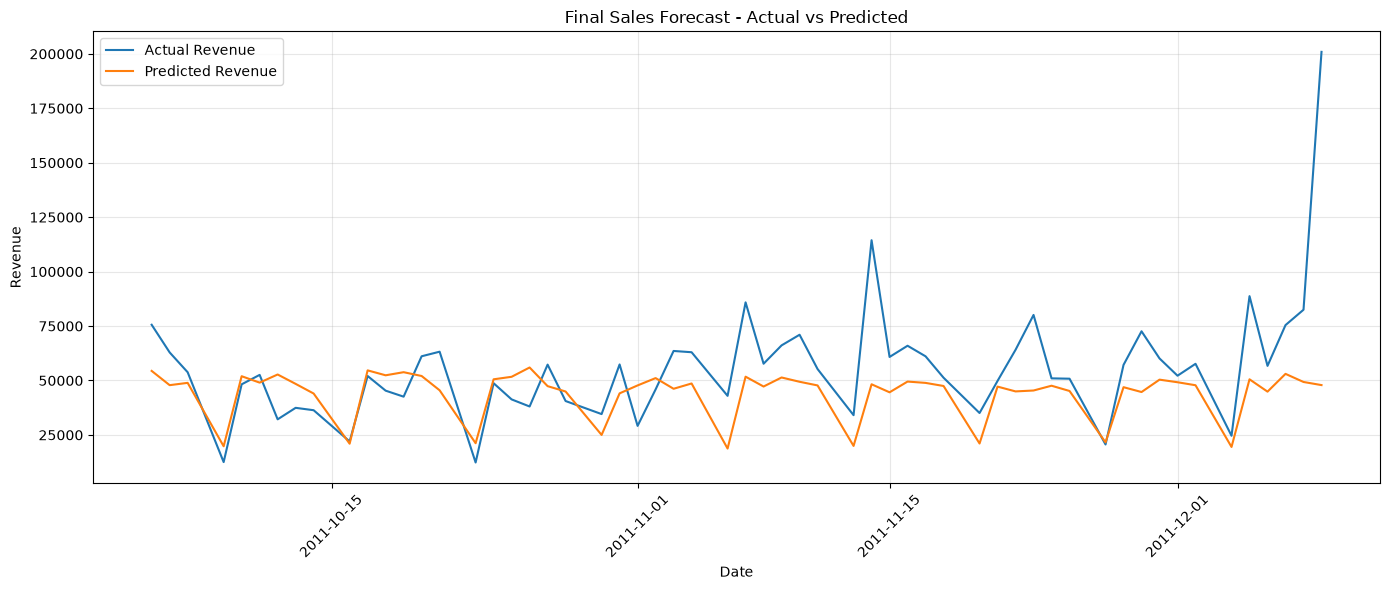

In [36]:
# Save final sales forecast visualization

plt.figure(figsize=(14, 6))

plt.plot(
    improved_results["Date"],
    improved_results["Actual_Revenue"],
    label="Actual Revenue"
)

plt.plot(
    improved_results["Date"],
    improved_results["Predicted_Revenue"],
    label="Predicted Revenue"
)

plt.title("Final Sales Forecast - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../visualizations/final_sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()